In [1]:
import pandas as pd


In [2]:
df = pd.read_csv(
    "../Data/raw_ai_student_impact_dataset (1).csv"
)

In [19]:
df["gpa_change"] = (
    df["Post_Semester_GPA"]
    - df["Pre_Semester_GPA"]
)


In [4]:
# GPA CHANGE PER MAJOR
df.groupby(
    "Major_Category"
)["gpa_change"].mean()

Major_Category
Arts          0.196902
Business      0.194325
Humanities    0.197976
Medical       0.201399
STEM          0.217302
Name: gpa_change, dtype: float64

In [5]:
#* GPA CHANGE AND RETENTION RATE PER SUBCRIPTION ( FREE OR PAID )
df.groupby(
    "Paid_Subscription"
)[["gpa_change", "Skill_Retention_Score"]].mean()

,gpa_change,Skill_Retention_Score
Paid_Subscription,,
False,0.200429,76.072040
True,0.206971,75.424609


In [6]:
# Average Gpa change of Students who used ai grouped by how many hours do they use ai at a weekly basis 
df.groupby(
    pd.cut(df["Weekly_GenAI_Hours"], bins=5)
)["gpa_change"].agg(["mean", "count"])

,mean,count
Weekly_GenAI_Hours,,
"(-0.04, 8.0]",0.202014,30762
"(8.0, 16.0]",0.228547,11590
"(16.0, 24.0]",0.186611,4488
"(24.0, 32.0]",0.162135,1854
"(32.0, 40.0]",0.121399,1306


In [7]:
# Retention rate of students based on their use of ai weekly
df.groupby(
    pd.cut(df["Weekly_GenAI_Hours"], bins=5)
)["Skill_Retention_Score"].agg(["mean"],)

,mean
Weekly_GenAI_Hours,
"(-0.04, 8.0]",76.240489
"(8.0, 16.0]",76.952620
"(16.0, 24.0]",75.730285
"(24.0, 32.0]",68.668711
"(32.0, 40.0]",65.487090


In [8]:
df.groupby(
    pd.cut(df["Anxiety_Level_During_Exams"], bins = 10)
)["Weekly_GenAI_Hours"].agg(["mean", "count"])

,mean,count
Anxiety_Level_During_Exams,,
"(0.991, 1.9]",5.999950,5655
"(1.9, 2.8]",6.523216,5752
"(2.8, 3.7]",7.146960,7806
"(3.7, 4.6]",7.809920,8749
"(4.6, 5.5]",8.402976,8222
"(5.5, 6.4]",9.280824,6107
"(6.4, 7.3]",11.118216,3850
"(7.3, 8.2]",12.438616,2088
"(8.2, 9.1]",14.888436,1151


In [9]:
# BURNOUT RISK BASED ON AI DEPENDENCY
df.groupby(
    "Burnout_Risk_Level"
    )["Perceived_AI_Dependency"].agg(["mean","count"])


,mean,count
Burnout_Risk_Level,,
High,4.641707,12487
Low,2.819965,16369
Medium,3.364879,21144


In [10]:
# Does AI dependency affect GPA change within each year?
df.groupby(
    ["Year_of_Study", "Perceived_AI_Dependency"]
)["gpa_change"].agg(["mean", "count"])

mean  count
Year_of_Study Perceived_AI_Dependency                 
Freshman      1                        0.132312   1640
              2                        0.137003   1976
              3                        0.137934   2305
              4                        0.134351   2197
              5                        0.137520   1457
              6                        0.122538    742
              7                        0.100214    370
              8                        0.085373    209
              9                        0.068409     88
              10                       0.071681     47
Graduate      1                        0.250568   1079
              2                        0.253870   1349
              3                        0.250855   1565
              4                        0.260212   1431
              5                        0.260069    988
              6                        0.242341    545
              7                        0.227826    276
              8                        0.249696    115
              9                        0.190600     65
              10                       0.098824     17
Junior        1                        0.226675   1595
              2                        0.226211   1936
              3                        0.233465   2352
              4                        0.230993   2231
              5                        0.231768   1488
              6                        0.215169    762
              7                        0.192997    382
              8                        0.196430    172
              9                        0.148976     82
              10                       0.133333     45
Senior        1                        0.240647   1599
              2                        0.242339   1890
              3                        0.252439   2231
              4                        0.251553   2055
              5                        0.249581   1420
              6                        0.240004    777
              7                        0.202864    369
              8                        0.168478    180
              9                        0.177400     75
              10                       0.072868     38
Sophomore     1                        0.177289   1390
              2                        0.179334   1723
              3                        0.187330   2025
              4                        0.181690   2020
              5                        0.176720   1392
              6                        0.168423    695
              7                        0.130105    325
              8                        0.147196    179
              9                        0.105706     68
              10                       0.156209     43

In [11]:
# GPA CHANGE BASED ON THEIR AI DEPENDENCY
df.groupby(
"Perceived_AI_Dependency"
)["gpa_change"].agg(["mean"])

,mean
Perceived_AI_Dependency,
1,0.202674
2,0.204884
3,0.210171
4,0.208057
5,0.207944
6,0.196108
7,0.168888
8,0.160255
9,0.135233


In [28]:
# Does higher Generative AI usage correspond to lower or higher skill retention?
df["score_bin"] = pd.cut(df["Skill_Retention_Score"], bins=10)
df.groupby("score_bin"
           )["Weekly_GenAI_Hours"].agg(["mean","count"])

,mean,count
score_bin,,
"(10.691, 19.702]",34.874000,5
"(19.702, 28.624]",33.346552,29
"(28.624, 37.546]",19.897500,124
"(37.546, 46.468]",14.532188,658
"(46.468, 55.39]",10.675750,2506
"(55.39, 64.312]",9.277740,6447
"(64.312, 73.234]",8.383718,11167
"(73.234, 82.156]",7.989535,12809
"(82.156, 91.078]",7.803095,9393


In [12]:
df.groupby(
    "Prompt_Engineering_Skill"
    )["gpa_change"].agg(["mean"])


,mean
Prompt_Engineering_Skill,
Advanced,0.248096
Beginner,0.185244
Intermediate,0.186924


In [13]:
df.to_csv(
    "../Data/cleaned_ai_student.csv",
    index=False
)

In [14]:
numeric = df.select_dtypes(include="number")

numeric.corr()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,gpa_change
Student_ID,1.000000,0.002275,0.001577,-0.001187,0.000648,0.002768,0.009670,-0.000602,-0.001737,-0.007413
Pre_Semester_GPA,0.002275,1.000000,-0.001084,-0.005671,-0.004620,0.000701,-0.000667,0.926781,0.099019,-0.104035
Weekly_GenAI_Hours,0.001577,-0.001084,1.000000,0.008411,-0.157368,0.665479,0.269080,-0.018600,-0.118099,-0.046479
Tool_Diversity,-0.001187,-0.005671,0.008411,1.000000,0.003565,0.006019,0.003189,0.025265,0.196952,0.081407
Traditional_Study_Hours,0.000648,-0.004620,-0.157368,0.003565,1.000000,-0.102625,-0.040935,0.137653,0.147565,0.376317
Perceived_AI_Dependency,0.002768,0.000701,0.665479,0.006019,-0.102625,1.000000,0.307620,-0.014180,-0.084324,-0.039342
Anxiety_Level_During_Exams,0.009670,-0.000667,0.269080,0.003189,-0.040935,0.307620,1.000000,-0.015909,-0.041556,-0.040420
Post_Semester_GPA,-0.000602,0.926781,-0.018600,0.025265,0.137653,-0.014180,-0.015909,1.000000,0.169616,0.277146
Skill_Retention_Score,-0.001737,0.099019,-0.118099,0.196952,0.147565,-0.084324,-0.041556,0.169616,1.000000,0.195833
gpa_change,-0.007413,-0.104035,-0.046479,0.081407,0.376317,-0.039342,-0.040420,0.277146,0.195833,1.000000


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt



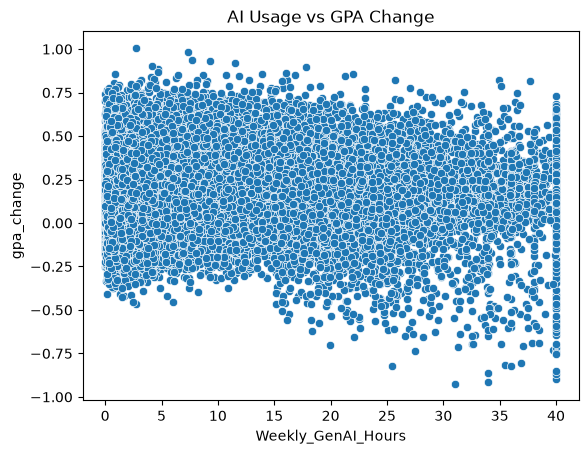

In [16]:
sns.scatterplot(
    data=df,
    x="Weekly_GenAI_Hours",
    y="gpa_change"
)

plt.title("AI Usage vs GPA Change")
plt.show()

### Interpretation

The scatter plot shows no clear upward trend between weekly AI usage and GPA change.

Data points remain widely dispersed across all AI usage levels, suggesting that increased AI usage alone does not strongly predict academic improvement.

This supports the correlation result (r ≈ -0.046).

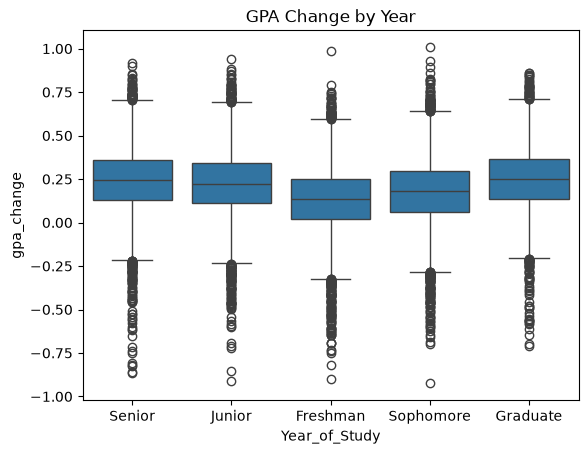

In [17]:
sns.boxplot(
    data=df,
    x="Year_of_Study",
    y="gpa_change"
)

plt.title("GPA Change by Year")
plt.show()

### Interpretation — GPA Change by Year

The boxplot shows that GPA change distributions are relatively similar across year levels.

Graduate students appear to have a slightly higher median GPA improvement compared to other groups, while Freshman students show slightly lower median improvement.

However, the overlap between distributions suggests that year of study alone may not strongly determine GPA change.

Outliers exist in every group, indicating that some students experienced unusually high or low GPA changes regardless of academic year.

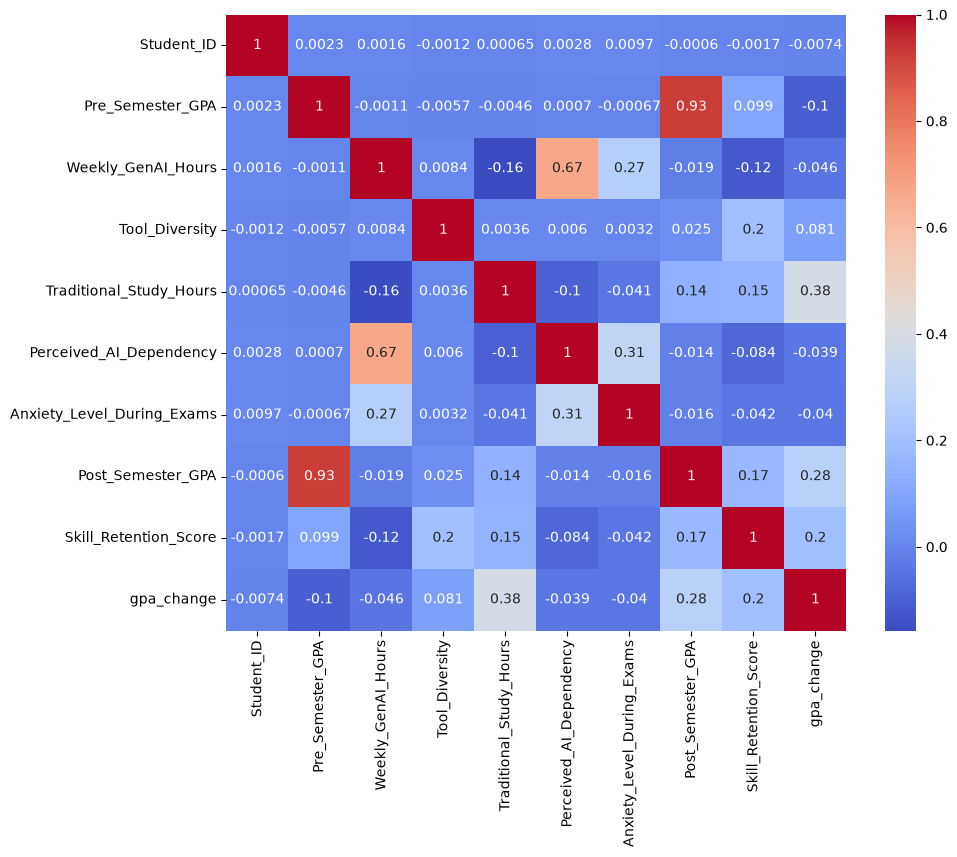

In [18]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Biggest findings
Highest correlation: Pre-semester GPA → Post-semester GPA (0.93)
- Previous academic performance was the strongest predictor of later academic performance.

Strongest AI finding: AI hours → AI dependency (0.67)
- Increased exposure to AI tools may increase reliance on them.

Best GPA improvement factor shown here: Traditional study hours → GPA change (0.38)
- Using AI more frequently did not appear to produce meaningful GPA improvement.

AI hours → GPA change: Almost none (-0.046)
- Traditional study habits appeared more connected to academic improvement than AI usage alone.

AI dependency → Anxiety: Slight increase (0.31)
- Students reporting greater dependency on AI also tended to report slightly higher anxiety during exams.

# FINAL OVERALL CONCLUSION 
This analysis suggests that Generative AI appears to function more as a support tool than a direct driver of academic improvement. Higher AI usage was associated more strongly with dependency than with GPA gains, while traditional study behavior remained more closely related to academic improvement.


# Research Questions + Answers (Revised)

## Academic Performance

### 1. Does increased Generative AI usage relate to higher GPA improvement?

Answer:
No strong relationship was found.

Weekly_GenAI_Hours ↔ GPA Change = -0.046.

AI usage alone did not show meaningful association with GPA improvement.

---

### 2. Is there an optimal range of weekly AI usage associated with the highest GPA gains?

Answer:
Based on grouped analysis, moderate AI usage (8–16 hours per week) showed the highest average GPA improvement.

Results:

* 0–8 hrs → 0.202
* 8–16 hrs → 0.229 ← highest
* 16–24 hrs → 0.187
* 24–32 hrs → 0.162
* 32–40 hrs → 0.121

This suggests moderate usage may be associated with better outcomes than excessive usage.

---

### 3. Do students with paid AI subscriptions show different academic outcomes than non-paying students?

Answer:
Paid users showed slightly higher average GPA change, but the difference was small.

Paid → 0.206
Non-paid → 0.200

No substantial academic advantage was observed.

---

### 4. Does prompt engineering skill relate to better academic performance?

Answer:
Yes.

Students with Advanced prompt engineering skill showed the highest average GPA improvement.

* Advanced → 0.248
* Intermediate → 0.187
* Beginner → 0.185

This suggests stronger prompting ability may be associated with improved academic outcomes.

---

### 5. Which factors appear most associated with GPA change?

Answer:

* Traditional Study Hours → 0.38
* Post Semester GPA → 0.28
* Skill Retention → 0.20

Traditional study showed stronger association than AI usage.

---

## Learning & Skill Retention

### 6. Does higher Generative AI usage correspond to lower or higher skill retention?

Answer:
Higher Generative AI usage is associated with lower skill retention.

There is a clear downward trend in skill retention as AI usage increases.

Retention Score	  Ai_weekly_Usage(hrs)
10.691 - 19.702	  34.874000	
19.702 - 28.624	  33.346552	
28.624 - 37.546	  19.897500	
37.546 - 46.468	  14.532188	
46.468 - 55.39	  10.675750	
55.39 - 64.312	  9.277740	
64.312 - 73.234	  8.383718	
73.234 - 82.156	  7.989535	
82.156 - 91.078	  7.803095	
91.078 - 100.0	  7.635718	
 

---

### 7. Do students with stronger AI dependency retain skills differently?

Answer:
Very weak negative relationship.

AI Dependency ↔ Skill Retention = -0.084.

---

### 8. Does tool diversity influence skill retention outcomes?

Answer:
Weak positive relationship.

Tool Diversity ↔ Skill Retention = 0.20.

---

## Study Behavior

### 9. How do traditional study hours compare with Generative AI usage in relation to GPA change?

Answer:
Traditional study showed stronger relationship.

Traditional Study → 0.38
AI Usage → -0.046

---

## Student Well-being

### 12. Is higher perceived AI dependency associated with increased burnout risk?

Answer:
Partially supported.

AI dependency showed weak positive relationships with stress indicators.

---

### 13. Does exam anxiety appear related to increased AI usage?

Answer:
Weak positive relationship.

Weekly_GenAI_Hours ↔ Anxiety = 0.27.

---

## Comparative Questions

### 17. Are academic improvements consistent across all study years?

Answer:
Yes.

The boxplot showed broadly similar GPA change distributions across year levels.

---

## Big Conclusion Question

### 18. Is moderate Generative AI usage associated with better academic outcomes than excessive usage?

Answer:
Partially yes.

The grouped analysis showed that students using AI moderately (8–16 hours/week) had the highest average GPA improvement, while heavier usage showed declining gains.
